In [ ]:
# %pip install --no-cache-dir torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# %pip install --no-cache-dir transformers datasets scikit-learn matplotlib seaborn pandas numpy tqdm
# %pip install --no-cache-dir flash-attn --no-build-isolation

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from tqdm.auto import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

d:\ML\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n{'='*70}")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f"{'='*70}\n")

# Hyperparameters
BATCH_SIZE = 32
LEARNING_RATE = 2e-4
NUM_EPOCHS = 10
HIDDEN_SIZE = 256
NUM_HEADS = 8
NUM_LAYERS = 2
MAX_LENGTH = 256
VOCAB_SIZE = 30000
TRAIN_SIZE = 5000  # Adjust based on available data
TEST_SIZE = 1000


Using device: cuda
GPU: NVIDIA GeForce RTX 3060
Memory Available: 12.88 GB



In [3]:
# Load SST-2 Dataset
print("Loading SST-2 Dataset...")

# Read sentences
sentences_df = pd.read_csv('./SST2-Data/stanfordSentimentTreebank/stanfordSentimentTreebank/datasetSentences.txt', 
                           sep='\t', encoding='utf-8')

# Read dictionary (phrase to phrase_id mapping)
dictionary_df = pd.read_csv('./SST2-Data/stanfordSentimentTreebank/stanfordSentimentTreebank/dictionary.txt', 
                            sep='|', names=['phrase', 'phrase_id'])

# Read sentiment labels (phrase_id to sentiment value)
sentiment_df = pd.read_csv('./SST2-Data/stanfordSentimentTreebank/stanfordSentimentTreebank/sentiment_labels.txt', 
                           sep='|')

# Read dataset split (sentence_index to train/dev/test)
split_df = pd.read_csv('./SST2-Data/stanfordSentimentTreebank/stanfordSentimentTreebank/datasetSplit.txt')

# Merge to get sentence with sentiment
# First, create a mapping from sentence to phrase_id
sentence_to_phrase = dict(zip(dictionary_df['phrase'], dictionary_df['phrase_id']))

# Get phrase_ids for sentences
sentences_df['phrase_id'] = sentences_df['sentence'].map(sentence_to_phrase)

# Merge with sentiment labels
data_df = sentences_df.merge(sentiment_df, left_on='phrase_id', right_on='phrase ids', how='inner')

# Merge with split information
data_df = data_df.merge(split_df, on='sentence_index', how='inner')

# Convert sentiment to binary labels (SST-2 uses 0.5 as threshold)
# sentiment < 0.5 = negative (0), sentiment >= 0.5 = positive (1)
data_df['label'] = (data_df['sentiment values'] >= 0.5).astype(int)

# Filter only binary sentiment (remove neutral)
# For strict binary classification, we can keep only clear positive/negative
data_df = data_df[(data_df['sentiment values'] <= 0.4) | (data_df['sentiment values'] >= 0.6)].copy()

# Split dataset: 1=train, 2=test, 3=dev
train_df = data_df[data_df['splitset_label'] == 1].reset_index(drop=True)
test_df = data_df[data_df['splitset_label'] == 2].reset_index(drop=True)

# Shuffle
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Select subset
train_texts = train_df['sentence'][:TRAIN_SIZE].tolist()
train_labels = train_df['label'][:TRAIN_SIZE].tolist()
test_texts = test_df['sentence'][:TEST_SIZE].tolist()
test_labels = test_df['label'][:TEST_SIZE].tolist()

print(f"Loaded SST-2: {len(train_texts)} train, {len(test_texts)} test samples")
print(f"Train label distribution: {pd.Series(train_labels).value_counts().to_dict()}")
print(f"Test label distribution: {pd.Series(test_labels).value_counts().to_dict()}")

Loading SST-2 Dataset...
Loaded SST-2: 5000 train, 1000 test samples
Train label distribution: {1: 2641, 0: 2359}
Test label distribution: {1: 507, 0: 493}


In [4]:
class SimpleTokenizer:
    """Simple tokenizer for text data"""
    def __init__(self, vocab_size=30000, max_length=256):
        self.vocab_size = vocab_size
        self.max_length = max_length
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}
        
    def fit(self, texts):
        """Build vocabulary from texts"""
        word_freq = {}
        for text in tqdm(texts, desc="Building vocabulary"):
            for word in text.lower().split():
                word_freq[word] = word_freq.get(word, 0) + 1
        
        # Sort by frequency and take top vocab_size - 2 (accounting for PAD and UNK)
        sorted_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
        for idx, (word, _) in enumerate(sorted_words[:self.vocab_size - 2], start=2):
            self.word2idx[word] = idx
            self.idx2word[idx] = word
        
        print(f"Vocabulary size: {len(self.word2idx)}")
        
    def encode(self, text):
        """Convert text to token ids"""
        tokens = [self.word2idx.get(word.lower(), 1) for word in text.split()]
        # Truncate or pad
        if len(tokens) > self.max_length:
            tokens = tokens[:self.max_length]
        else:
            tokens = tokens + [0] * (self.max_length - len(tokens))
        return tokens
    
    def create_attention_mask(self, tokens):
        """Create attention mask (1 for real tokens, 0 for padding)"""
        return [1 if token != 0 else 0 for token in tokens]

# Initialize and fit tokenizer
print("\nTokenizing dataset...")
tokenizer = SimpleTokenizer(vocab_size=VOCAB_SIZE, max_length=MAX_LENGTH)
tokenizer.fit(train_texts)

# Tokenize datasets
train_input_ids = [tokenizer.encode(text) for text in tqdm(train_texts, desc="Tokenizing train")]
train_attention_masks = [tokenizer.create_attention_mask(ids) for ids in train_input_ids]
test_input_ids = [tokenizer.encode(text) for text in tqdm(test_texts, desc="Tokenizing test")]
test_attention_masks = [tokenizer.create_attention_mask(ids) for ids in test_input_ids]


Tokenizing dataset...


Building vocabulary: 100%|██████████| 5000/5000 [00:00<00:00, 434823.14it/s]


Vocabulary size: 12278


Tokenizing test: 100%|██████████| 1000/1000 [00:00<00:00, 200024.04it/s]


In [5]:
class SST2Dataset(Dataset):
    def __init__(self, input_ids, attention_masks, labels):
        self.input_ids = torch.LongTensor(input_ids)
        self.attention_masks = torch.FloatTensor(attention_masks)
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_masks[idx],
            'label': self.labels[idx]
        }

# Create datasets
train_dataset = SST2Dataset(train_input_ids, train_attention_masks, train_labels)
test_dataset = SST2Dataset(test_input_ids, test_attention_masks, test_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Dataloaders created: {len(train_loader)} train batches, {len(test_loader)} test batches")

Dataloaders created: 157 train batches, 32 test batches


In [6]:
class TraditionalAttention(nn.Module):
    """Traditional scaled dot-product attention"""
    def __init__(self, hidden_size, num_heads, dropout=0.1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_heads = num_heads
        self.head_dim = hidden_size // num_heads
        
        self.q_linear = nn.Linear(hidden_size, hidden_size)
        self.k_linear = nn.Linear(hidden_size, hidden_size)
        self.v_linear = nn.Linear(hidden_size, hidden_size)
        self.out_linear = nn.Linear(hidden_size, hidden_size)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, attention_mask=None):
        batch_size, seq_len, _ = x.shape
        
        # Linear projections and reshape
        q = self.q_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        
        # Compute attention scores (memory intensive operation)
        scores = torch.matmul(q, k.transpose(-2, -1)) / np.sqrt(self.head_dim)
        
        if attention_mask is not None:
            scores = scores.masked_fill(attention_mask.unsqueeze(1).unsqueeze(2) == 0, -1e9)
        
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        # Apply attention to values
        context = torch.matmul(attn_weights, v)
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, self.hidden_size)
        
        return self.out_linear(context)

In [7]:
class FlashAttentionWrapper(nn.Module):
    """Flash Attention wrapper with fallback"""
    def __init__(self, hidden_size, num_heads, dropout=0.1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_heads = num_heads
        self.head_dim = hidden_size // num_heads
        
        self.q_linear = nn.Linear(hidden_size, hidden_size)
        self.k_linear = nn.Linear(hidden_size, hidden_size)
        self.v_linear = nn.Linear(hidden_size, hidden_size)
        self.out_linear = nn.Linear(hidden_size, hidden_size)
        self.dropout = dropout
        
        # Try to import flash attention
        try:
            from flash_attn import flash_attn_func
            self.flash_attn_func = flash_attn_func
            self.use_flash = True
            print("Using Flash Attention")
        except ImportError:
            print("Using PyTorch Efficient Attention (scaled_dot_product_attention)")
            self.use_flash = False
        
    def forward(self, x, attention_mask=None):
        batch_size, seq_len, _ = x.shape
        
        # Linear projections
        q = self.q_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim)
        k = self.k_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim)
        v = self.v_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim)
        
        if self.use_flash:
            # Use Flash Attention (requires specific format)
            output = self.flash_attn_func(q, k, v, dropout_p=self.dropout if self.training else 0.0)
        else:
            # Use PyTorch's optimized attention
            q = q.transpose(1, 2)  # (batch, num_heads, seq_len, head_dim)
            k = k.transpose(1, 2)
            v = v.transpose(1, 2)
            output = F.scaled_dot_product_attention(q, k, v, dropout_p=self.dropout if self.training else 0.0)
            output = output.transpose(1, 2)  # (batch, seq_len, num_heads, head_dim)
        
        output = output.contiguous().view(batch_size, seq_len, self.hidden_size)
        return self.out_linear(output)

In [8]:
class SentimentClassifier(nn.Module):
    """Transformer-based sentiment classifier"""
    def __init__(self, vocab_size, hidden_size=256, num_heads=8, num_layers=2, 
                 num_classes=2, dropout=0.1, use_flash=False):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, hidden_size, padding_idx=0)
        self.pos_encoding = nn.Parameter(torch.randn(1, 512, hidden_size) * 0.02)
        
        # Attention layers
        self.attention_layers = nn.ModuleList([
            FlashAttentionWrapper(hidden_size, num_heads, dropout) if use_flash 
            else TraditionalAttention(hidden_size, num_heads, dropout)
            for _ in range(num_layers)
        ])
        
        self.layer_norms = nn.ModuleList([nn.LayerNorm(hidden_size) for _ in range(num_layers)])
        self.feed_forwards = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_size, hidden_size * 4),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_size * 4, hidden_size),
                nn.Dropout(dropout)
            ) for _ in range(num_layers)
        ])
        self.ff_layer_norms = nn.ModuleList([nn.LayerNorm(hidden_size) for _ in range(num_layers)])
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes)
        )
        
    def forward(self, input_ids, attention_mask=None):
        # Embedding + positional encoding
        x = self.embedding(input_ids)
        seq_len = x.size(1)
        x = x + self.pos_encoding[:, :seq_len, :]
        
        # Transformer layers
        for attn, ln1, ff, ln2 in zip(self.attention_layers, self.layer_norms, 
                                       self.feed_forwards, self.ff_layer_norms):
            # Attention with residual connection
            attn_out = attn(x, attention_mask)
            x = ln1(x + attn_out)
            
            # Feed-forward with residual connection
            ff_out = ff(x)
            x = ln2(x + ff_out)
        
        # Global average pooling with attention mask
        if attention_mask is not None:
            mask_expanded = attention_mask.unsqueeze(-1).expand(x.size())
            sum_embeddings = torch.sum(x * mask_expanded, 1)
            sum_mask = mask_expanded.sum(1)
            x = sum_embeddings / sum_mask.clamp(min=1e-9)
        else:
            x = x.mean(dim=1)
        
        # Classification
        return self.classifier(x)

In [9]:
def train_epoch(model, dataloader, optimizer, criterion, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    
    progress_bar = tqdm(dataloader, desc='Training')
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
        optimizer.step()
        
        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    
    return avg_loss, accuracy


def evaluate(model, dataloader, criterion, device):
    """Evaluate the model"""
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return {
        'loss': total_loss / len(dataloader),
        'accuracy': accuracy_score(all_labels, all_preds),
        'f1': f1_score(all_labels, all_preds, average='binary'),
        'precision': precision_score(all_labels, all_preds, average='binary'),
        'recall': recall_score(all_labels, all_preds, average='binary'),
        'predictions': all_preds,
        'labels': all_labels
    }


def measure_inference_time(model, dataloader, device, num_iterations=50):
    """Measure average inference time per batch"""
    model.eval()
    times = []
    
    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            if i >= num_iterations:
                break
            
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            
            # Warm-up iterations
            if i < 5:
                _ = model(input_ids, attention_mask)
                continue
            
            # Measure time
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            
            start = time.time()
            _ = model(input_ids, attention_mask)
            
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            
            times.append(time.time() - start)
    
    return np.mean(times), np.std(times)

In [10]:
print("\n" + "="*70)
print("TRAINING MODEL WITH TRADITIONAL ATTENTION")
print("="*70)

model_trad = SentimentClassifier(
    vocab_size=VOCAB_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    use_flash=False
).to(device)

print(f"Model parameters: {sum(p.numel() for p in model_trad.parameters()):,}")

optimizer_trad = torch.optim.AdamW(model_trad.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

# Training
trad_start_time = time.time()
trad_history = {'train_loss': [], 'train_acc': []}

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    train_loss, train_acc = train_epoch(model_trad, train_loader, optimizer_trad, criterion, device)
    trad_history['train_loss'].append(train_loss)
    trad_history['train_acc'].append(train_acc)
    print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}")

trad_train_time = time.time() - trad_start_time

# Evaluation
print("\nEvaluating Traditional Attention Model...")
trad_metrics = evaluate(model_trad, test_loader, criterion, device)
trad_inf_time, trad_inf_std = measure_inference_time(model_trad, test_loader, device)

print(f"\n{'='*70}")
print("TRADITIONAL ATTENTION RESULTS")
print(f"{'='*70}")
print(f"Training Time: {trad_train_time:.2f} seconds")
print(f"Test Accuracy: {trad_metrics['accuracy']:.4f}")
print(f"Test F1 Score: {trad_metrics['f1']:.4f}")
print(f"Test Precision: {trad_metrics['precision']:.4f}")
print(f"Test Recall: {trad_metrics['recall']:.4f}")
print(f"Inference Time: {trad_inf_time*1000:.2f} ± {trad_inf_std*1000:.2f} ms/batch")
print(f"{'='*70}")

# Save results
results_traditional = {
    'train_time': trad_train_time,
    'metrics': trad_metrics,
    'inference_time': trad_inf_time,
    'inference_std': trad_inf_std,
    'history': trad_history
}

# Clear memory
del model_trad, optimizer_trad
torch.cuda.empty_cache()
gc.collect()


TRAINING MODEL WITH TRADITIONAL ATTENTION
Model parameters: 9,456,898

Epoch 1/10


Training: 100%|██████████| 157/157 [00:06<00:00, 24.95it/s, loss=0.5212]


Train Loss: 0.6617, Train Accuracy: 0.5938

Epoch 2/10


Training: 100%|██████████| 157/157 [00:05<00:00, 26.83it/s, loss=0.4424]


Train Loss: 0.5966, Train Accuracy: 0.6842

Epoch 3/10


...

Training: 100%|██████████| 157/157 [00:05<00:00, 26.77it/s, loss=0.0006]


Train Loss: 0.0566, Train Accuracy: 0.9820

Evaluating Traditional Attention Model...


Evaluating: 100%|██████████| 32/32 [00:00<00:00, 90.34it/s]



TRADITIONAL ATTENTION RESULTS
Training Time: 59.12 seconds
Test Accuracy: 0.6990
Test F1 Score: 0.7357
Test Precision: 0.6630
Test Recall: 0.8264
Inference Time: 10.49 ± 1.40 ms/batch


24

In [11]:
print("\n" + "="*70)
print("TRAINING MODEL WITH FLASH ATTENTION")
print("="*70)

model_flash = SentimentClassifier(
    vocab_size=VOCAB_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    use_flash=True
).to(device)

print(f"Model parameters: {sum(p.numel() for p in model_flash.parameters()):,}")

optimizer_flash = torch.optim.AdamW(model_flash.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

# Training
flash_start_time = time.time()
flash_history = {'train_loss': [], 'train_acc': []}

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    train_loss, train_acc = train_epoch(model_flash, train_loader, optimizer_flash, criterion, device)
    flash_history['train_loss'].append(train_loss)
    flash_history['train_acc'].append(train_acc)
    print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}")

flash_train_time = time.time() - flash_start_time

# Evaluation
print("\nEvaluating Flash Attention Model...")
flash_metrics = evaluate(model_flash, test_loader, criterion, device)
flash_inf_time, flash_inf_std = measure_inference_time(model_flash, test_loader, device)

print(f"\n{'='*70}")
print("FLASH ATTENTION RESULTS")
print(f"{'='*70}")
print(f"Training Time: {flash_train_time:.2f} seconds")
print(f"Test Accuracy: {flash_metrics['accuracy']:.4f}")
print(f"Test F1 Score: {flash_metrics['f1']:.4f}")
print(f"Test Precision: {flash_metrics['precision']:.4f}")
print(f"Test Recall: {flash_metrics['recall']:.4f}")
print(f"Inference Time: {flash_inf_time*1000:.2f} ± {flash_inf_std*1000:.2f} ms/batch")
print(f"{'='*70}")

# Save results
results_flash = {
    'train_time': flash_train_time,
    'metrics': flash_metrics,
    'inference_time': flash_inf_time,
    'inference_std': flash_inf_std,
    'history': flash_history
}


TRAINING MODEL WITH FLASH ATTENTION
Using PyTorch Efficient Attention (scaled_dot_product_attention)
Using PyTorch Efficient Attention (scaled_dot_product_attention)
Model parameters: 9,456,898

Epoch 1/10


Training: 100%|██████████| 157/157 [00:04<00:00, 32.30it/s, loss=0.5390]


Train Loss: 0.6782, Train Accuracy: 0.5558

Epoch 2/10


Training: 100%|██████████| 157/157 [00:04<00:00, 32.15it/s, loss=0.6326]


Train Loss: 0.6031, Train Accuracy: 0.6694

Epoch 3/10


...

Train Loss: 0.0721, Train Accuracy: 0.9720

Epoch 10/10


Training: 100%|██████████| 157/157 [00:04<00:00, 32.84it/s, loss=0.4682]


Train Loss: 0.0518, Train Accuracy: 0.9836

Evaluating Flash Attention Model...


Evaluating: 100%|██████████| 32/32 [00:00<00:00, 128.44it/s]



FLASH ATTENTION RESULTS
Training Time: 48.41 seconds
Test Accuracy: 0.6940
Test F1 Score: 0.7467
Test Precision: 0.6434
Test Recall: 0.8895
Inference Time: 7.15 ± 0.94 ms/batch


In [18]:
print("\n" + "="*70)
print("FINAL COMPARISON: TRADITIONAL vs FLASH ATTENTION (SST-2 Dataset)")
print("="*70)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score', 'Precision', 'Recall', 
               'Train Time (s)', 'Inference (ms/batch)'],
    'Traditional': [
        results_traditional['metrics']['accuracy'],
        results_traditional['metrics']['f1'],
        results_traditional['metrics']['precision'],
        results_traditional['metrics']['recall'],
        results_traditional['train_time'],
        results_traditional['inference_time'] * 1000
    ],
    'Flash': [
        results_flash['metrics']['accuracy'],
        results_flash['metrics']['f1'],
        results_flash['metrics']['precision'],
        results_flash['metrics']['recall'],
        results_flash['train_time'],
        results_flash['inference_time'] * 1000
    ]
})

# Calculate improvement
comparison_df['Improvement (%)'] = (
    (abs(comparison_df['Flash'] - comparison_df['Traditional'])) / 
    comparison_df['Traditional'] * 100
)

print("\n" + comparison_df.to_string(index=False))

# Calculate speedups
train_speedup = ((results_traditional['train_time'] - results_flash['train_time']) / 
                 results_traditional['train_time'] * 100)
inf_speedup = ((results_traditional['inference_time'] - results_flash['inference_time']) / 
               results_traditional['inference_time'] * 100)

print(f"\n{'='*70}")
print("SPEEDUP SUMMARY")
print(f"{'='*70}")
print(f"Training Speedup: {train_speedup:+.1f}% {'(Flash is faster)' if train_speedup > 0 else '(Traditional is faster)'}")
print(f"Inference Speedup: {inf_speedup:+.1f}% {'(Flash is faster)' if inf_speedup > 0 else '(Traditional is faster)'}")
print(f"{'='*70}")


FINAL COMPARISON: TRADITIONAL vs FLASH ATTENTION (SST-2 Dataset)

              Metric  Traditional     Flash  Improvement (%)
            Accuracy     0.699000  0.694000         0.715308
            F1 Score     0.735733  0.746689         1.489078
           Precision     0.662975  0.643367         2.957589
              Recall     0.826430  0.889546         7.637232
      Train Time (s)    59.118984 48.407788        18.118032
Inference (ms/batch)    10.486550  7.153502        31.784025

SPEEDUP SUMMARY
Training Speedup: +18.1% (Flash is faster)
Inference Speedup: +31.8% (Flash is faster)



Visualization saved as 'flash_attention_comparison_sst2.png'


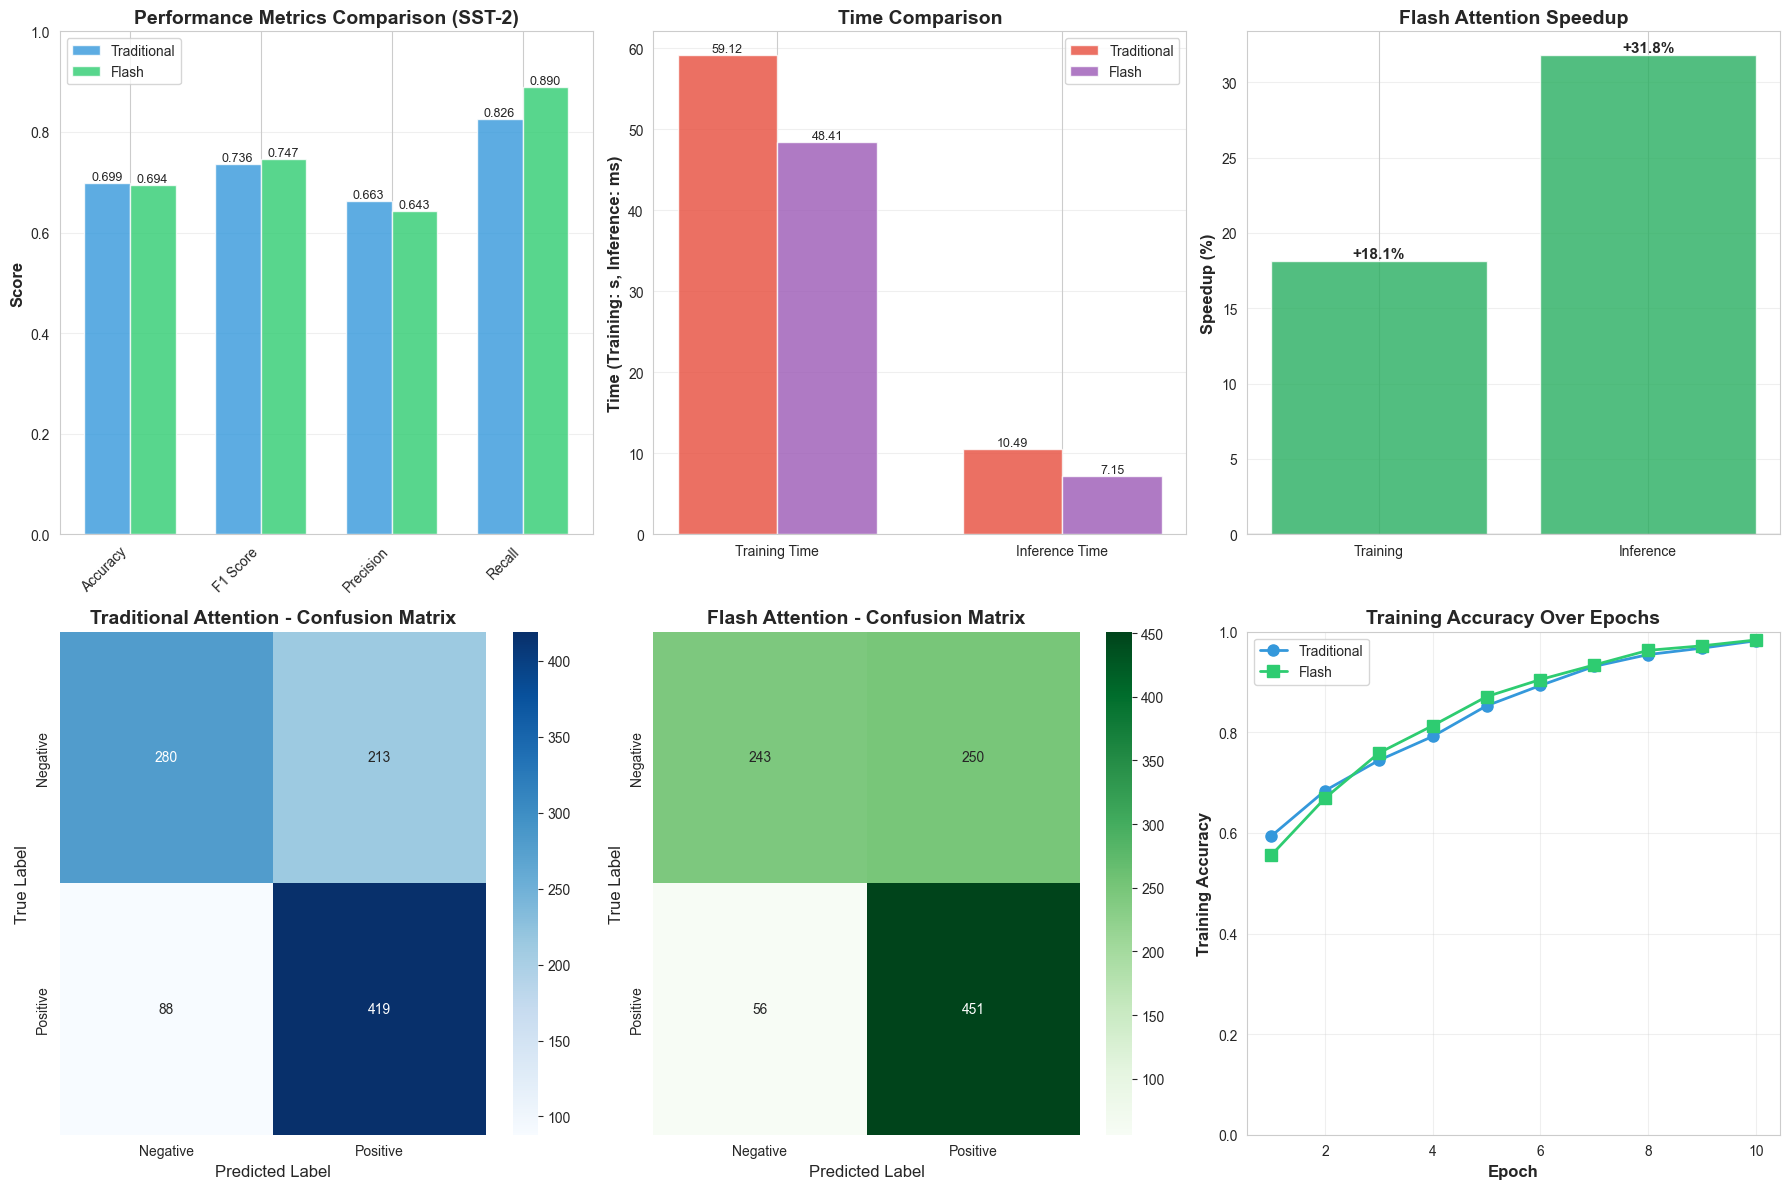

In [19]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Performance Metrics Comparison
ax = axes[0, 0]
metrics_data = comparison_df[comparison_df['Metric'].isin(['Accuracy', 'F1 Score', 'Precision', 'Recall'])]
x = np.arange(len(metrics_data))
width = 0.35
bars1 = ax.bar(x - width/2, metrics_data['Traditional'], width, label='Traditional', 
               alpha=0.8, color='#3498db')
bars2 = ax.bar(x + width/2, metrics_data['Flash'], width, label='Flash', 
               alpha=0.8, color='#2ecc71')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Performance Metrics Comparison (SST-2)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_data['Metric'], rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.0])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# 2. Time Comparison
ax = axes[0, 1]
time_categories = ['Training Time', 'Inference Time']
trad_times = [results_traditional['train_time'], results_traditional['inference_time']*1000]
flash_times = [results_flash['train_time'], results_flash['inference_time']*1000]
x = np.arange(len(time_categories))
bars1 = ax.bar(x - width/2, trad_times, width, label='Traditional', alpha=0.8, color='#e74c3c')
bars2 = ax.bar(x + width/2, flash_times, width, label='Flash', alpha=0.8, color='#9b59b6')
ax.set_ylabel('Time (Training: s, Inference: ms)', fontsize=12, fontweight='bold')
ax.set_title('Time Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(time_categories)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# 3. Speedup Visualization
ax = axes[0, 2]
speedups = [train_speedup, inf_speedup]
categories = ['Training', 'Inference']
colors = ['#27ae60' if s > 0 else '#e74c3c' for s in speedups]
bars = ax.bar(categories, speedups, color=colors, alpha=0.8)
ax.set_ylabel('Speedup (%)', fontsize=12, fontweight='bold')
ax.set_title('Flash Attention Speedup', fontsize=14, fontweight='bold')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar, speedup in zip(bars, speedups):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{speedup:+.1f}%', ha='center', 
            va='bottom' if height > 0 else 'top', fontsize=11, fontweight='bold')

# 4. Confusion Matrix - Traditional
ax = axes[1, 0]
cm_trad = confusion_matrix(results_traditional['metrics']['labels'], 
                           results_traditional['metrics']['predictions'])
sns.heatmap(cm_trad, annot=True, fmt='d', ax=ax, cmap='Blues', cbar=True,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
ax.set_title('Traditional Attention - Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)

# 5. Confusion Matrix - Flash
ax = axes[1, 1]
cm_flash = confusion_matrix(results_flash['metrics']['labels'], 
                            results_flash['metrics']['predictions'])
sns.heatmap(cm_flash, annot=True, fmt='d', ax=ax, cmap='Greens', cbar=True,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
ax.set_title('Flash Attention - Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)

# 6. Training History
ax = axes[1, 2]
epochs = range(1, NUM_EPOCHS + 1)
ax.plot(epochs, results_traditional['history']['train_acc'], 'o-', 
        label='Traditional', color='#3498db', linewidth=2, markersize=8)
ax.plot(epochs, results_flash['history']['train_acc'], 's-', 
        label='Flash', color='#2ecc71', linewidth=2, markersize=8)
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Training Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Training Accuracy Over Epochs', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.0])

plt.tight_layout()
plt.savefig('flash_attention_comparison_sst2.png', dpi=300, bbox_inches='tight')
print("\nVisualization saved as 'flash_attention_comparison_sst2.png'")
plt.show()

In [20]:
print("\n" + "="*70)
print("DETAILED ANALYSIS")
print("="*70)

# Memory efficiency analysis
if torch.cuda.is_available():
    print(f"\nGPU Memory Analysis:")
    print(f"Max Memory Allocated: {torch.cuda.max_memory_allocated() / 1e9:.2f} GB")
    print(f"Max Memory Reserved: {torch.cuda.max_memory_reserved() / 1e9:.2f} GB")

# Performance consistency
print(f"\nInference Time Consistency:")
print(f"Traditional: {results_traditional['inference_time']*1000:.2f} ± {results_traditional['inference_std']*1000:.2f} ms")
print(f"Flash: {results_flash['inference_time']*1000:.2f} ± {results_flash['inference_std']*1000:.2f} ms")

# Model complexity
print(f"\nModel Configuration:")
print(f"Hidden Size: {HIDDEN_SIZE}")
print(f"Number of Heads: {NUM_HEADS}")
print(f"Number of Layers: {NUM_LAYERS}")
print(f"Vocabulary Size: {VOCAB_SIZE}")
print(f"Max Sequence Length: {MAX_LENGTH}")

# Dataset statistics
print(f"\nDataset Statistics (SST-2):")
print(f"Training Samples: {len(train_dataset)}")
print(f"Test Samples: {len(test_dataset)}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Number of Epochs: {NUM_EPOCHS}")

print("\n" + "="*70)
print("EXPERIMENT COMPLETED SUCCESSFULLY!")
print("="*70)

# Save results to CSV
comparison_df.to_csv('attention_comparison_results_sst2.csv', index=False)
print("\nResults saved to 'attention_comparison_results_sst2.csv'")


DETAILED ANALYSIS

GPU Memory Analysis:
Max Memory Allocated: 0.78 GB
Max Memory Reserved: 0.91 GB

Inference Time Consistency:
Traditional: 10.49 ± 1.40 ms
Flash: 7.15 ± 0.94 ms

Model Configuration:
Hidden Size: 256
Number of Heads: 8
Number of Layers: 2
Vocabulary Size: 30000
Max Sequence Length: 256

Dataset Statistics (SST-2):
Training Samples: 5000
Test Samples: 1000
Batch Size: 32
Number of Epochs: 10

EXPERIMENT COMPLETED SUCCESSFULLY!

Results saved to 'attention_comparison_results_sst2.csv'
